In [1]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "paths.json").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing config/paths.json")

REPO_ROOT = find_repo_root()
UTILS_DIR = REPO_ROOT / "code" / "utils"
if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

from project_paths import ensure_project_dirs, load_project_paths

PATHS = ensure_project_dirs(load_project_paths(REPO_ROOT))

import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import starbars


In [2]:
# Define the base paths
subjects = ['sub-HDP01', 'sub-HDP02', 'sub-HDP03', 'sub-HDP04', 'sub-HDP06', 'sub-HDP08', 'sub-HDP09', 'sub-HDP10', 'sub-HDP12', 'sub-HDP13', 'sub-HDP15', 'sub-HDP17', 'sub-HDP18', 'sub-HDP19'] 
sessions = ["ses-01", "ses-02"]
output_dir = PATHS["surface_figures_root"]
pkpd_output_dir = PATHS["pk_pd_figures_root"]
(output_dir / "CMRglc").mkdir(parents=True, exist_ok=True)
(output_dir / "Figures").mkdir(parents=True, exist_ok=True)
participants_data = pd.read_csv(PATHS["participants_file"], sep="\t")

# Load R output data
results_kinfitr = pd.read_csv(PATHS["kinfitr_output_root"] / '02_Outcomes' / '03_model_outcomes' / 'Patlak_outcomes.tsv', sep="\t")
results_kinfitr['condition'] = results_kinfitr['condition'].replace({'Verum': 'DMT + har'})


### Plot whole brain CMRglc differences

In [3]:
# Preprocess DataFrame
df_plot = results_kinfitr.copy()
df_net = df_plot[df_plot['Region'] == 'whole_brain']


In [4]:
from scipy.stats import ttest_rel

# Pivot the dataframe to get one row per 'sub', with columns for each condition
df_pivot = df_net.pivot(index='sub', columns='condition', values='CMRglc')

# Drop any rows with missing data (if any subjects are missing a condition)
df_paired = df_pivot.dropna(subset=['Placebo', 'DMT + har'])

# Perform paired t-test
t_stat, p_val = ttest_rel(df_paired['DMT + har'], df_paired['Placebo'], alternative='greater')

print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

t-statistic: 2.581, p-value: 0.0114


/var/folders/gj/d44qt0ss6bbchgr8g2vwyj4r0000gn/T/ipykernel_38912/1137542917.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([label.get_text() for label in ax.get_yticklabels()], weight='bold', fontsize=12)


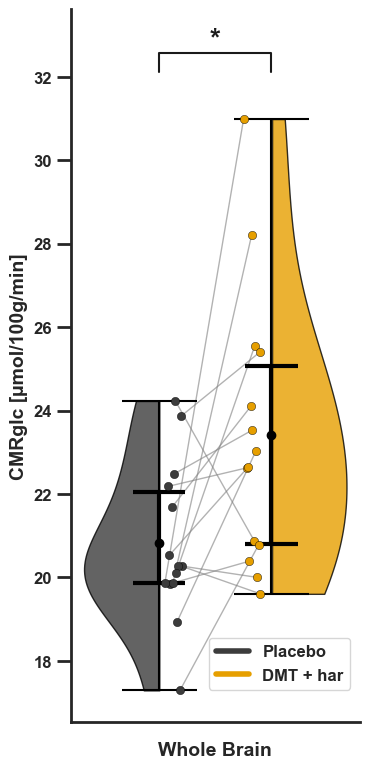

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib

sns.set_theme(style="ticks", rc={"figure.figsize": (20, 10)}, font_scale=1.4)
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})

# Plotting setup
fig, ax = plt.subplots(figsize=(4, 8))
offset = 0.15
jitter_strength = 0.015
conditions = ['Placebo', 'DMT + har']
colors = {'Placebo': '#3C3C3C', 'DMT + har': '#E69F00'}

# Violin plots
for side, condition in zip(['left', 'right'], conditions):
    df_cond = df_net[df_net['condition'] == condition]
    values = df_cond['CMRglc'].values

    parts = ax.violinplot(
        dataset=values,
        positions=[0 - offset if condition == 'Placebo' else 0 + offset],
        showextrema=True,
        widths=0.4
    )

    for pc in parts['bodies']:
        pc.set_facecolor(colors[condition])
        pc.set_edgecolor('black')
        pc.set_alpha(0.8)
        path = pc.get_paths()[0]
        vertices = path.vertices
        mean_x = np.mean(vertices[:, 0])

        if side == 'left':
            vertices[:, 0] = np.clip(vertices[:, 0], -np.inf, mean_x)
            ax.plot(0 - offset, np.mean(values), 'o', color='black', markersize=6)
            q1, q3 = np.percentile(values, [25, 75])
            ax.vlines(0 - offset, q1, q3, color='black', linestyle='-', lw=3)
            ax.hlines(q1, 0 - offset - 0.07, 0 - offset + 0.07, color='black', lw=3)
            ax.hlines(q3, 0 - offset - 0.07, 0 - offset + 0.07, color='black', lw=3)
        else:
            vertices[:, 0] = np.clip(vertices[:, 0], mean_x, np.inf)
            ax.plot(0 + offset, np.mean(values), 'o', color='black', markersize=6)
            q1, q3 = np.percentile(values, [25, 75])
            ax.vlines(0 + offset, q1, q3, color='black', linestyle='-', lw=3)
            ax.hlines(q1, 0 + offset - 0.07, 0 + offset + 0.07, color='black', lw=3)
            ax.hlines(q3, 0 + offset - 0.07, 0 + offset + 0.07, color='black', lw=3)

    parts['cbars'].set_color('black')
    parts['cmins'].set_color('black')
    parts['cmaxes'].set_color('black')

# Connect paired participant points
subjects = df_net['sub'].unique()
for subj in subjects:
    subj_data = df_net[df_net['sub'] == subj]
    if len(subj_data) == 2:
        y_placebo = subj_data[subj_data['condition'] == 'Placebo']['CMRglc'].values[0]
        y_dmt = subj_data[subj_data['condition'] == 'DMT + har']['CMRglc'].values[0]

        jitter = np.random.normal(0, jitter_strength)
        x_placebo = 0 - offset * 0.7 + jitter
        x_dmt = 0 + offset * 0.7 + jitter

        ax.plot([x_placebo, x_dmt], [y_placebo, y_dmt], color='gray', alpha=0.6, lw=1, zorder=1)
        ax.scatter(x_placebo, y_placebo, color=colors['Placebo'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)
        ax.scatter(x_dmt, y_dmt, color=colors['DMT + har'], zorder=2, alpha=1, edgecolor='black', linewidth=0.3)

# Formatting
sns.despine()
ax.set_xticks([0])
ax.set_xticklabels(['Whole Brain'], fontsize=14, weight='bold')
ax.set_yticklabels([label.get_text() for label in ax.get_yticklabels()], weight='bold', fontsize=12)
ax.set_ylabel('CMRglc [µmol/100g/min]', fontsize=14, weight='bold')
ax.set_xlabel(None)
#ax.set_ylim(10, 22)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.tick_params(axis='y', which='both', width=2, length=10)
ax.tick_params(axis='x', which='both', width=2, color='white', length=10)

# Custom legend
handles = [matplotlib.lines.Line2D([0], [0], color=color, lw=4) for color in colors.values()]
labels = list(colors.keys())
ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.45, 0.13), fontsize=12)

plt.tight_layout()

# Statistical annotations
pval = p_val ## from kinfitr script
#annotations = [(('whole_brain', 'Placebo'), ('whole_brain','DMT + har'), pval)]
annotations = [(-offset, offset, pval)]
starbars.draw_annotation(annotations, fontsize=20, text_distance=0.02, top_margin=0)#, bar_margin=0)
#draw_flat_annotations(ax, annotations, top_margin=0.01, text_distance=0.005, fontsize=26)

plt.savefig(output_dir / "CMRglc" / "CMRglc_whole_brain_violin_connected.png", dpi=600, bbox_inches='tight')

## Create composite plot with correlations

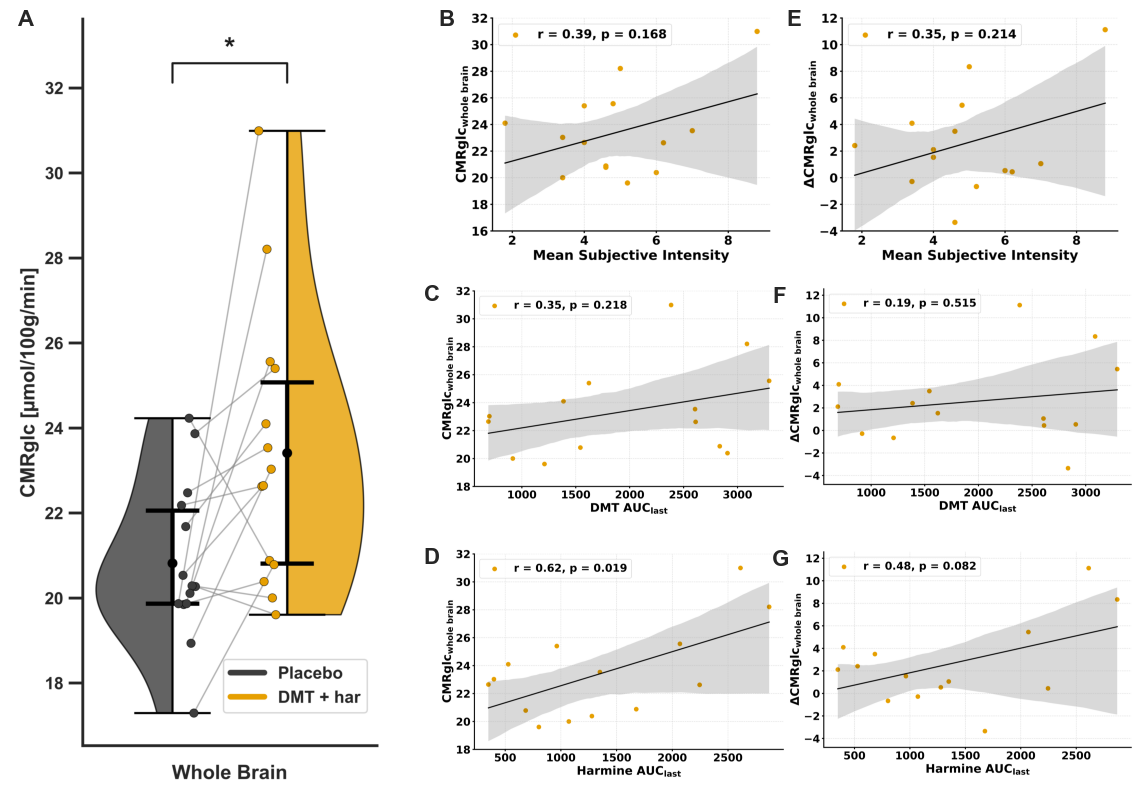

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg

# Load images
img_a = mpimg.imread(output_dir / "CMRglc" / "CMRglc_whole_brain_violin_connected.png")
img_b = mpimg.imread(pkpd_output_dir / "correlations_CMRglc_with_mean_intensity.png")
img_c = mpimg.imread(pkpd_output_dir / "correlations_CMRglc_with_AUC_DMT_concentrations.png")
img_d = mpimg.imread(pkpd_output_dir / "correlations_CMRglc_with_AUC_Harmine_concentrations.png")
img_e = mpimg.imread(pkpd_output_dir / "correlations_delta_CMRglc_with_mean_intensity.png")
img_f = mpimg.imread(pkpd_output_dir / "correlations_delta_CMRglc_with_AUC_DMT_concentrations.png")
img_g = mpimg.imread(pkpd_output_dir / "correlations_delta_CMRglc_with_AUC_Harmine_concentrations.png")

# Create figure and grid layout
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(
    3, 3,
    width_ratios=[1.1, 0.8, 0.8],
    height_ratios=[1, 1, 1],
    wspace=-0.001,
    hspace=0.02,
)

# Panel A — full height on left
ax_a = plt.subplot(gs[:, 0])
ax_a.imshow(img_a)
ax_a.axis('off')
ax_a.text(0.02, 1.0, 'A', transform=ax_a.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

# Original CMRglc correlations
ax_b = plt.subplot(gs[0, 1])
ax_b.imshow(img_b)
ax_b.axis('off')
ax_b.text(-0.04, 1.0, 'B', transform=ax_b.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

ax_c = plt.subplot(gs[1, 1])
ax_c.imshow(img_c)
ax_c.axis('off')
ax_c.text(-0.04, 1.0, 'C', transform=ax_c.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

ax_d = plt.subplot(gs[2, 1])
ax_d.imshow(img_d)
ax_d.axis('off')
ax_d.text(-0.04, 1.0, 'D', transform=ax_d.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

# Delta CMRglc correlations
ax_e = plt.subplot(gs[0, 2])
ax_e.imshow(img_e)
ax_e.axis('off')
ax_e.text(-0.04, 1.0, 'E', transform=ax_e.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

ax_f = plt.subplot(gs[1, 2])
ax_f.imshow(img_f)
ax_f.axis('off')
ax_f.text(-0.04, 1.0, 'F', transform=ax_f.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

ax_g = plt.subplot(gs[2, 2])
ax_g.imshow(img_g)
ax_g.axis('off')
ax_g.text(-0.04, 1.0, 'G', transform=ax_g.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

# Manual spacing instead of tight_layout to avoid warnings
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01)

# Save and show the composite figure
plt.savefig(output_dir / "Figures" / "CMRglc_whole_brain_composite.png", dpi=600, bbox_inches='tight')
plt.show()


## Composite Plot surface-based analysis

In [7]:
# Load images
img_a = mpimg.imread(output_dir / "CMRglc" / "drug_cmrglc_avg_desc-sm6.png")
img_b = mpimg.imread(output_dir / "CMRglc" / "placebo_cmrglc_avg_desc-sm6.png")
img_c = mpimg.imread(output_dir / "CMRglc" / "delta_cmrglc_avg_desc-sm6.png")
img_d = mpimg.imread(output_dir / "CMRglc" / "cmrglc_t_stat_map_p05-sm6.png")
img_e = mpimg.imread(output_dir / "CMRglc" / "cmrglc_t_stat_map_p01-sm6.png")
img_f = mpimg.imread(output_dir / "CMRglc" / "Fsaverage_desc-sm6_Hist_plot_with_means.png")
img_g = mpimg.imread(output_dir / "CMRglc" / "vertexwise_shannon_entropy_desc-sm6.png")

/var/folders/gj/d44qt0ss6bbchgr8g2vwyj4r0000gn/T/ipykernel_38912/226302712.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


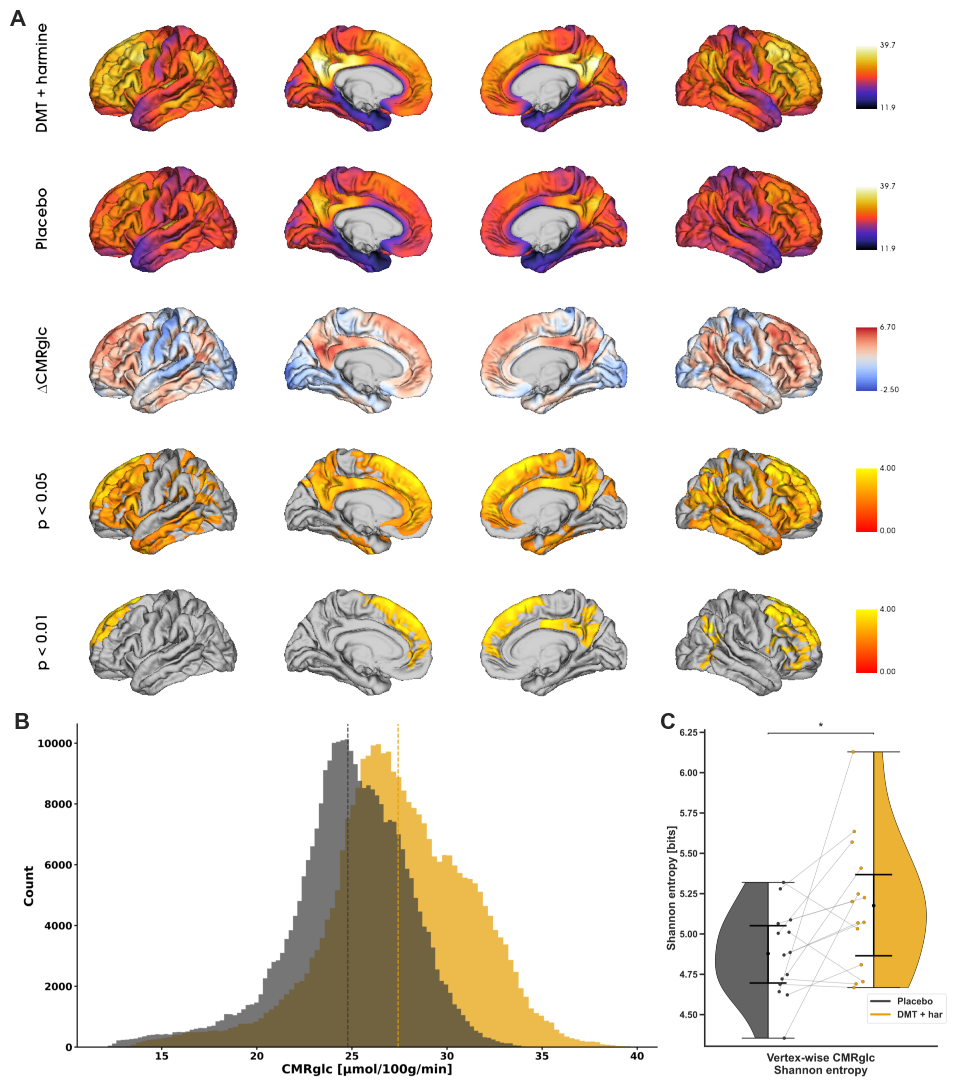

In [8]:

# Define figure and grid layout
fig = plt.figure(figsize=(12, 14))
gs = gridspec.GridSpec(
    6, 4, 
    width_ratios=[2, 2, 2, 2.7],    # columns 0–2 = wider, column 3 = narrower
    height_ratios=[1, 1, 1, 1, 1, 2.65],  # last small row for spacing/padding
    wspace=0.01, hspace=0.0
)

# Row 1–5: Full-width images (span all 4 columns)
ax_a = plt.subplot(gs[0, :])
ax_a.imshow(img_a)
ax_a.axis('off')
ax_a.text(-0.01, 1.02, "A", transform=ax_a.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

ax_b = plt.subplot(gs[1, :])
ax_b.imshow(img_b)
ax_b.axis('off')

ax_c = plt.subplot(gs[2, :])
ax_c.imshow(img_c)
ax_c.axis('off')

ax_d = plt.subplot(gs[3, :])
ax_d.imshow(img_d)
ax_d.axis('off')

ax_e = plt.subplot(gs[4, :])
ax_e.imshow(img_e)
ax_e.axis('off')

# Row 5: Two side-by-side panels (violin wide, histogram narrow)
ax_f = plt.subplot(gs[5, 0:3])  # spans first 3 columns
ax_f.imshow(img_f)
ax_f.axis('off')
ax_f.text(-0.01, 1.02, "B", transform=ax_f.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

ax_g = plt.subplot(gs[5, 3])  # last column
ax_g.imshow(img_g)
ax_g.axis('off')
ax_g.text(-0.01, 1.02, "C", transform=ax_g.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

# Final padding row (invisible)
#plt.subplot(gs[5, :]).axis('off')

# Save or show
plt.tight_layout()
plt.savefig(output_dir / "Figures" / "surface_analysis_composite_figure_new.png", dpi=600, bbox_inches='tight')
plt.show()

## Composite Plot Network-based analyses

/var/folders/gj/d44qt0ss6bbchgr8g2vwyj4r0000gn/T/ipykernel_38912/1388784683.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


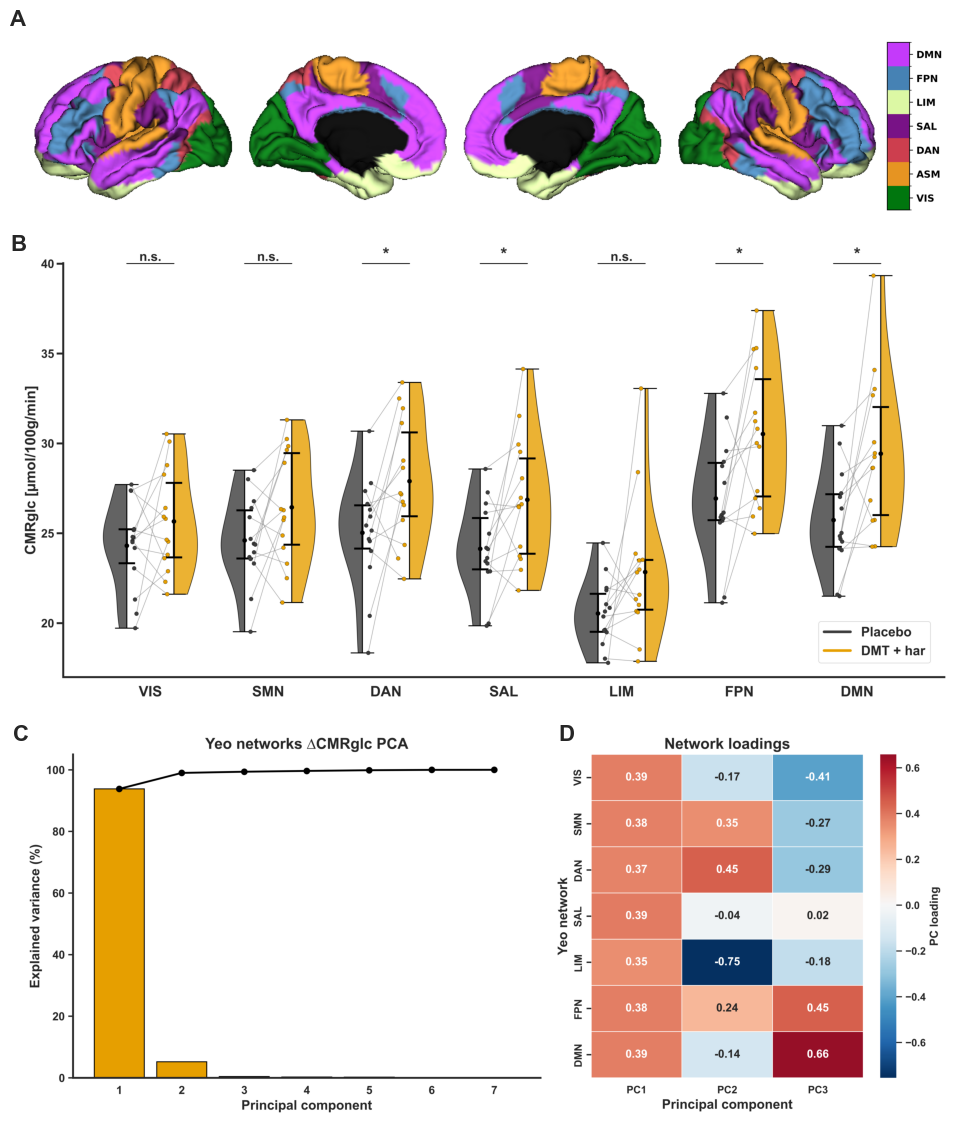

In [9]:
# Load images
img_a = mpimg.imread(output_dir / "CMRglc" / "yeo_networks_with_labels.png")
img_b = mpimg.imread(output_dir / "CMRglc" / "CMRglc_yeo_violin_connected_desc-sm6.png")
img_c = mpimg.imread(output_dir / "CMRglc" / "delta_cmrglc_yeo7_pca_summary_desc-sm6.png")



# Define figure and grid layout
fig = plt.figure(figsize=(12, 14))
gs = gridspec.GridSpec(
    3, 1, 
    width_ratios=[1],    # columns 0–2 = wider, column 3 = narrower
    height_ratios=[1.1, 2.2, 1.85],  # last small row for spacing/padding
    wspace=0.01, hspace=0.0
)

# Row 1–3: Full-width images (span all 1 column)
ax_a = plt.subplot(gs[0, :])
ax_a.imshow(img_a)
ax_a.axis('off')
ax_a.text(-0.01, 1.02, "A", transform=ax_a.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

ax_b = plt.subplot(gs[1, :])
ax_b.imshow(img_b)
ax_b.axis('off')
ax_b.text(-0.01, 1.02, "B", transform=ax_b.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

ax_c = plt.subplot(gs[2, :])
pos = ax_c.get_position()
ax_c.set_position([pos.x0, pos.y0 - 0.02, pos.width, pos.height])
ax_c.imshow(img_c)
ax_c.axis('off')
ax_c.text(-0.01, 1.02, "C", transform=ax_c.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
ax_c.text(0.58, 1.02, "D", transform=ax_c.transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

# Final padding row (invisible)
#plt.subplot(gs[5, :]).axis('off')

# Save or show
plt.tight_layout()
plt.savefig(output_dir / "Figures" / "yeo_network_analysis_composite_figure_new.png", dpi=600, bbox_inches='tight')
plt.show()


### compare the placebo scan order

n(ses-01)=6, n(ses-02)=8
Shapiro p (ses-01): 0.3488
Shapiro p (ses-02): 0.7431

Test used: Welch independent t-test
t-statistic: -0.837, p-value: 0.4208

Descriptives:
ses-01 mean±sd: 20.367 ± 1.170
ses-02 mean±sd: 21.158 ± 2.305


/var/folders/gj/d44qt0ss6bbchgr8g2vwyj4r0000gn/T/ipykernel_38912/4073838978.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([lab.get_text() for lab in ax.get_yticklabels()],


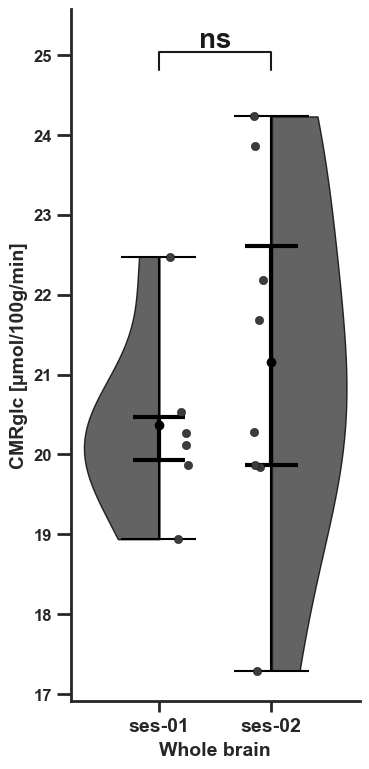

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

sns.set_theme(style="ticks", rc={"figure.figsize": (20, 10)}, font_scale=1.4)
plt.rcParams.update({"font.weight": "bold", "axes.labelweight": "bold"})

# =========================================================
# 1) Build placebo-only dataframe + derive placebo session
# =========================================================
df_plot = results_kinfitr.copy()

# whole_brain + placebo only
df_net = df_plot[(df_plot["Region"] == "whole_brain") & (df_plot["condition"] == "Placebo")].copy()

# map participant_id ("sub-HDP01") -> sub ("HDP01") and derive placebo session
participants_tmp = participants_data.copy()
participants_tmp["sub"] = participants_tmp["participant_id"].str.replace(r"^sub-", "", regex=True)

placebo_session_map = (
    participants_tmp.set_index("sub")["drug_ses-01"]
    .map({"Placebo": "ses-01", "Verum": "ses-02"})
)

df_net["session"] = df_net["sub"].map(placebo_session_map)

# keep only ses-01/ses-02 and ensure one row per subject (placebo scan)
df_pl = (
    df_net[df_net["session"].isin(["ses-01", "ses-02"])]
    .dropna(subset=["CMRglc"])
    .drop_duplicates(subset=["sub"])
    .copy()
)

# =========================================================
# 2) Stats: ses-01 vs ses-02 (independent groups)
# =========================================================
g1 = df_pl.loc[df_pl["session"] == "ses-01", "CMRglc"].to_numpy()
g2 = df_pl.loc[df_pl["session"] == "ses-02", "CMRglc"].to_numpy()

print(f"n(ses-01)={len(g1)}, n(ses-02)={len(g2)}")

alpha = 0.05
p_shapiro_g1 = shapiro(g1).pvalue if len(g1) >= 3 else np.nan
p_shapiro_g2 = shapiro(g2).pvalue if len(g2) >= 3 else np.nan
print(f"Shapiro p (ses-01): {p_shapiro_g1:.4f}")
print(f"Shapiro p (ses-02): {p_shapiro_g2:.4f}")

both_normal = (np.isnan(p_shapiro_g1) or p_shapiro_g1 > alpha) and (np.isnan(p_shapiro_g2) or p_shapiro_g2 > alpha)
alternative = "two-sided"

if both_normal:
    test_name = "Welch independent t-test"
    stat, pval = ttest_ind(g1, g2, equal_var=False, alternative=alternative)
    print(f"\nTest used: {test_name}")
    print(f"t-statistic: {stat:.3f}, p-value: {pval:.4f}")
else:
    test_name = "Mann–Whitney U"
    stat, pval = mannwhitneyu(g1, g2, alternative=alternative)
    print(f"\nTest used: {test_name}")
    print(f"U-statistic: {stat:.3f}, p-value: {pval:.4f}")

print("\nDescriptives:")
print(f"ses-01 mean±sd: {np.mean(g1):.3f} ± {np.std(g1, ddof=1):.3f}")
print(f"ses-02 mean±sd: {np.mean(g2):.3f} ± {np.std(g2, ddof=1):.3f}")

# =========================================================
# 3) Plot: split violin + points + annotation
# =========================================================
fig, ax = plt.subplots(figsize=(4, 8))
offset = 0.15
sessions = ["ses-01", "ses-02"]
placebo_color = "#3C3C3C"

# half-violins + mean + IQR
for side, ses in zip(["left", "right"], sessions):
    df_ses = df_pl[df_pl["session"] == ses]
    values = df_ses["CMRglc"].dropna().values

    parts = ax.violinplot(
        dataset=values,
        positions=[-offset if ses == "ses-01" else +offset],
        showextrema=True,
        widths=0.4
    )

    for pc in parts["bodies"]:
        pc.set_facecolor(placebo_color)
        pc.set_edgecolor("black")
        pc.set_alpha(0.8)

        path = pc.get_paths()[0]
        vertices = path.vertices
        mean_x = np.mean(vertices[:, 0])

        x0 = -offset if ses == "ses-01" else +offset

        # clip to half violin
        if side == "left":
            vertices[:, 0] = np.clip(vertices[:, 0], -np.inf, mean_x)
        else:
            vertices[:, 0] = np.clip(vertices[:, 0], mean_x, np.inf)

        # mean dot + IQR
        ax.plot(x0, np.mean(values), "o", color="black", markersize=6)
        q1, q3 = np.percentile(values, [25, 75])
        ax.vlines(x0, q1, q3, color="black", lw=3)
        ax.hlines([q1, q3], x0 - 0.07, x0 + 0.07, color="black", lw=3)

    parts["cbars"].set_color("black")
    parts["cmins"].set_color("black")
    parts["cmaxes"].set_color("black")

# individual points (no connecting lines)
np.random.seed(0)
jitter_strength = 0.015
for ses, x0 in zip(sessions, [-offset * 0.7, +offset * 0.7]):
    y = df_pl.loc[df_pl["session"] == ses, "CMRglc"].values
    x = x0 + np.random.normal(0, jitter_strength, size=len(y))
    ax.scatter(x, y, color=placebo_color, zorder=2, alpha=1,
               edgecolor="black", linewidth=0.3)

# formatting
sns.despine()
ax.set_xticks([-offset, +offset])
ax.set_xticklabels(["ses-01", "ses-02"], fontsize=14, weight="bold")
ax.set_ylabel("CMRglc [µmol/100g/min]", fontsize=14, weight="bold")
ax.set_xlabel("Whole brain", fontsize=14, weight="bold")
ax.set_yticklabels([lab.get_text() for lab in ax.get_yticklabels()],
                   weight="bold", fontsize=12)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
ax.tick_params(axis="y", which="both", width=2, length=10)
ax.tick_params(axis="x", which="both", width=2, length=8)

plt.tight_layout()

# annotation uses the pval computed above
annotations = [(-offset, +offset, pval)]
starbars.draw_annotation(annotations, fontsize=20, text_distance=0.02, top_margin=0)

plt.savefig(
    output_dir / "CMRglc" / "CMRglc_whole_brain_placebo_ses01_vs_ses02_violin.png",
    dpi=600,
    bbox_inches="tight"
)

### test if there is a stronger effect on one hemisphere

In [11]:
from scipy.stats import ttest_rel
import pandas as pd

# --- keep only the two conditions and the two hemisphere ROIs
df_hemi = df_plot[
    df_plot["condition"].isin(["Placebo", "DMT + har"])
    & df_plot["Region"].isin(["left_cortex", "right_cortex"])
].copy()

def paired_t_by_region(df, region, alternative="greater"):
    tmp = df[df["Region"] == region].pivot(index="sub", columns="condition", values="CMRglc")
    tmp = tmp.dropna(subset=["Placebo", "DMT + har"])
    t_stat, p_val = ttest_rel(tmp["DMT + har"], tmp["Placebo"], alternative=alternative)
    return tmp, t_stat, p_val

# 1) Within-hemisphere: does CMRglc increase under DMT+har vs Placebo?
left_tbl, t_left, p_left = paired_t_by_region(df_hemi, "left_cortex", alternative="greater")
right_tbl, t_right, p_right = paired_t_by_region(df_hemi, "right_cortex", alternative="greater")

print(f"Left cortex:  t={t_left:.3f}, p={p_left:.4f} (one-sided, DMT+har > Placebo), n={len(left_tbl)}")
print(f"Right cortex: t={t_right:.3f}, p={p_right:.4f} (one-sided, DMT+har > Placebo), n={len(right_tbl)}")

# 2) Hemispheric asymmetry of the drug effect:
#    test whether (DMT-Placebo) is larger in RIGHT than LEFT across subjects
#    i.e., delta_right - delta_left > 0
delta_left = (left_tbl["DMT + har"] - left_tbl["Placebo"]).rename("delta_left")
delta_right = (right_tbl["DMT + har"] - right_tbl["Placebo"]).rename("delta_right")

df_delta = pd.concat([delta_left, delta_right], axis=1).dropna()
t_asym, p_asym = ttest_rel(df_delta["delta_right"], df_delta["delta_left"], alternative="greater")

print(f"Asymmetry (delta_right > delta_left): t={t_asym:.3f}, p={p_asym:.4f} (one-sided), n={len(df_delta)}")

# Optional: report mean deltas (useful for abstract wording)
print(
    f"Mean Δ left  = {df_delta['delta_left'].mean():.3f} µmol/100g/min; "
    f"Mean Δ right = {df_delta['delta_right'].mean():.3f} µmol/100g/min; "
    f"Mean (ΔR-ΔL) = {(df_delta['delta_right']-df_delta['delta_left']).mean():.3f}"
)

Left cortex:  t=2.348, p=0.0177 (one-sided, DMT+har > Placebo), n=14
Right cortex: t=2.756, p=0.0082 (one-sided, DMT+har > Placebo), n=14
Asymmetry (delta_right > delta_left): t=1.096, p=0.1465 (one-sided), n=14
Mean Δ left  = 2.578 µmol/100g/min; Mean Δ right = 2.799 µmol/100g/min; Mean (ΔR-ΔL) = 0.221
